# Taller: Programación Orientada a Objetos para Gestión de Datos
**Bootcamp PY4 — Python y Manipulación de Datos**

---

En este taller vas a construir, paso a paso, un **pipeline de datos** completo usando los pilares de la Programación Orientada a Objetos (POO):

- **Abstracción** — definir contratos que todas las piezas deben cumplir.
- **Herencia** — reutilizar y extender comportamiento entre clases.
- **Encapsulamiento** — proteger los datos internos de cada componente.
- **Polimorfismo** — intercambiar piezas sin romper el resto del sistema.

Al final del taller habrás construido algo así:

```
DataComponent (abstracta)
       |
  +-----------+
  |           |
DataLoader  DataCleaner  <-- también usa ValidatorMixin + LoggerMixin
                |
           DataAnalyst
```




---
## Configuración inicial

Antes de empezar, vamos a importar todo lo que vamos a necesitar durante el taller y a crear el dataset de ejemplo con el que trabajaremos.


In [27]:
# Instalacion de dependencias (ejecutar solo si no las tienes)
# !pip install pandas matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from abc import ABC, abstractmethod
import os

print("Librerias cargadas correctamente.")


Librerias cargadas correctamente.


### Dataset de ejemplo

Vamos a trabajar con un archivo CSV simulado de ventas. Ejecuta la celda siguiente para crear el archivo en tu disco — así el `DataLoader` tendrá algo que leer.


In [28]:
# Creamos un CSV de ventas con valores nulos y tipos mixtos para practicar limpieza
np.random.seed(42)
n = 200

data = {
    "fecha": pd.date_range("2024-01-01", periods=n, freq="D").astype(str),
    "producto": np.random.choice(["Laptop", "Mouse", "Teclado", "Monitor", None], n),
    "categoria": np.random.choice(["Electronica", "Accesorios", "Perifericos"], n),
    "cantidad": np.random.randint(1, 20, n).astype(float),
    "precio_unitario": np.round(np.random.uniform(10, 1500, n), 2),
    "region": np.random.choice(["Norte", "Sur", "Centro", None], n),
}

# Introducimos algunos nulos artificiales
df_raw = pd.DataFrame(data)
df_raw.loc[np.random.choice(df_raw.index, 15, replace=False), "cantidad"] = np.nan
df_raw.loc[np.random.choice(df_raw.index, 10, replace=False), "precio_unitario"] = np.nan

# Guardamos el CSV
df_raw.to_csv("ventas.csv", index=False)
print(f"Archivo 'ventas.csv' creado con {len(df_raw)} filas.")
print(df_raw.head())


Archivo 'ventas.csv' creado con 200 filas.
        fecha producto    categoria  cantidad  precio_unitario  region
0  2024-01-01  Monitor   Accesorios      19.0           945.06  Centro
1  2024-01-02     None   Accesorios      17.0           880.63     Sur
2  2024-01-03  Teclado   Accesorios      19.0          1352.73   Norte
3  2024-01-04     None  Perifericos       5.0            77.72     Sur
4  2024-01-05     None  Perifericos       9.0           428.64  Centro


---
# Fase 1: Arquitectura Base y Mixins

Antes de escribir una sola linea de logica de negocio, vamos a definir la **arquitectura** del sistema. Esto es pensar como ingenieros: primero el contrato, luego la implementacion.

## Paso 1: La clase abstracta `DataComponent`

Una **clase abstracta** es como un contrato firmado. Le dice a cualquier clase que la herede: *"si quieres formar parte de este sistema, debes implementar el metodo `execute()`"*.

En Python usamos el modulo `abc` (Abstract Base Classes):
- `ABC` — hace que la clase sea abstracta.
- `@abstractmethod` — marca metodos que las subclases **estan obligadas** a implementar.

**Por que nos sirve esto en un pipeline?**  
Porque despues podemos tratar a `DataLoader`, `DataCleaner` y `DataAnalyst` como si fueran el mismo tipo de objeto y llamar `.execute()` en todos sin saber los detalles internos.


In [29]:
# Paso 1: Clase abstracta DataComponent
# ---------------------------------------------------------------------------

class DataComponent(ABC):  # Clase base abstracta para todos los componentes

    @abstractmethod  # Obliga a las subclases a implementar este metodo
    def execute(self):  # Metodo principal que ejecutara cada componente
        """Metodo que todas las subclases deben implementar."""  # Documentacion del metodo
        pass  # No hace nada aqui; la implementacion va en las subclases

    def __repr__(self):  # Define como se muestra el objeto al imprimirlo (para que no imprime algo feo como "<__main__.DataLoader object at 0x7f8a12345678>")
        return f"{self.__class__.__name__}()"  # Devuelve el nombre de la clase, por ejemplo: DataLoader()

**Prueba rapida:** intenta instanciar `DataComponent()` directamente. Deberias obtener un `TypeError`. Esto confirma que el contrato funciona.


In [30]:
# Prueba: intenta ejecutar esta celda y observa el error
# component = DataComponent()


## Paso 2: Los Mixins — herramientas reutilizables

Un **Mixin** es una clase pequena y enfocada que aporta una capacidad especifica, sin ser una clase base completa. No se instancia sola; se usa combinandola con herencia multiple.

Vamos a crear dos:

### `ValidatorMixin`
Proporciona metodos para verificar que un archivo existe y que un DataFrame tiene las columnas esperadas.

### `LoggerMixin`
Proporciona un metodo `log()` para imprimir mensajes con formato en consola, facilitando el seguimiento del pipeline.

> **Nota de diseno:** Los Mixins no tienen `__init__` propio (o si lo tienen, llaman a `super().__init__()`). Asi no interfieren con la cadena de herencia.


In [31]:
# Paso 2a: ValidatorMixin
# ---------------------------------------------------------------------------
# Requisitos:
#   - Metodo validate_file(filepath): verifica que el archivo exista en disco.
#     Lanza FileNotFoundError si no existe.
#   - Metodo validate_columns(df, required_cols): verifica que el DataFrame
#     tenga todas las columnas requeridas. Lanza ValueError si falta alguna.

class ValidatorMixin:  # Mixin para validaciones reutilizables

    def validate_file(self, filepath):  # Verifica que el archivo exista
        if not os.path.exists(filepath):  # Comprueba si la ruta existe
            raise FileNotFoundError(
                f"El archivo no existe: {filepath}"
            )  # Lanza error si no se encuentra

    def validate_columns(self, df, required_cols):  # Verifica columnas requeridas
        missing_cols = [
            col for col in required_cols if col not in df.columns # "Para cada columna (col) en la lista de columnas requeridas (required_cols), guarda la columna en missing_cols si no está en el DataFrame (df.columns)."
        ]  # Busca columnas faltantes

        if missing_cols:  # Si falta al menos una columna
            raise ValueError(
                f"Faltan las columnas: {missing_cols}"
            )  # Lanza error indicando cuales faltan


In [32]:
# Prueba de ValidatorMixin
# ---------------------------------------------------------------------------

class ValidatorTest(ValidatorMixin):  # Hereda solo las funciones de ValidatorMixin
    pass  # No necesita codigo adicional

validator = ValidatorTest()  # Crea una instancia de prueba

validator.validate_file("ventas.csv")  # Verifica si el archivo existe.
# Proba de cambiar el nombre!


In [ ]:
# Paso 2b: LoggerMixin
# ---------------------------------------------------------------------------
# Requisitos:
#   - Metodo log(mensaje, nivel="INFO"): imprime un mensaje con el formato:
#     [NIVEL] NombreDeClase: mensaje

class LoggerMixin:  # Mixin para mostrar mensajes en consola

    def log(self, mensaje, nivel="INFO"):  # Registra un mensaje con un nivel
        print(
            f"[{nivel}] {self.__class__.__name__}: {mensaje}"
        )  # Muestra el nivel, la clase y el mensaje

In [ ]:
# Prueba de LoggerMixin
# ---------------------------------------------------------------------------

class LoggerTest(LoggerMixin):  # Hereda solo las funciones de LoggerMixin
    pass  # No necesita codigo adicional

logger = LoggerTest()  # Crea una instancia de prueba

logger.log("Mensaje informativo")  # Prueba el nivel por defecto (INFO)
logger.log("Ocurrio un error", nivel="ERROR")  # Prueba un nivel personalizado

[INFO] LoggerTest: Mensaje informativo
[ERROR] LoggerTest: Ocurrio un error


---
# Fase 2: Ingesta y Transformacion

Ya tenemos la arquitectura. Ahora construimos las piezas que hacen el trabajo real.

## Paso 3: `DataLoader`

Esta clase se encarga de **leer datos crudos** desde un archivo CSV. Sus responsabilidades son:

1. Verificar que el archivo existe (usando `ValidatorMixin`).
2. Cargar el CSV en un DataFrame de Pandas.
3. Registrar lo que hace (usando `LoggerMixin`).

Un detalle importante: la ruta del archivo se guarda como **atributo privado** (`__file_path`). Esto es encapsulamiento — el resto del sistema no debe modificar la ruta una vez que el objeto fue creado.


In [ ]:
# Paso 3: DataLoader
# ---------------------------------------------------------------------------
# Requisitos:
#   - Hereda de: DataComponent, ValidatorMixin, LoggerMixin
#   - Constructor recibe: file_path (str)
#   - Guarda file_path como atributo privado (__file_path)
#   - Implementa execute()

class DataLoader(DataComponent, ValidatorMixin, LoggerMixin):  # Componente para cargar datos

    def __init__(self, file_path):  # Inicializa la ruta del archivo
        self.__file_path = file_path  # Guarda la ruta como atributo privado

    def execute(self):  # Ejecuta la carga del archivo
        self.validate_file(self.__file_path)  # Verifica que el archivo exista

        df = pd.read_csv(self.__file_path)  # Lee el archivo CSV

        self.log(
            f"Archivo cargado correctamente ({df.shape[0]} filas, {df.shape[1]} columnas)"
        )  # Registra informacion de la carga

        return df  # Devuelve el DataFrame

In [ ]:
# Prueba
loader = DataLoader("ventas.csv")  # Crea el cargador
df = loader.execute()  # Carga los datos

print(df.head())  # Muestra las primeras filas

[INFO] DataLoader: Archivo cargado correctamente (200 filas, 6 columnas)
        fecha producto    categoria  cantidad  precio_unitario  region
0  2024-01-01  Monitor   Accesorios      19.0           945.06  Centro
1  2024-01-02      NaN   Accesorios      17.0           880.63     Sur
2  2024-01-03  Teclado   Accesorios      19.0          1352.73   Norte
3  2024-01-04      NaN  Perifericos       5.0            77.72     Sur
4  2024-01-05      NaN  Perifericos       9.0           428.64  Centro


## Paso 4: `DataCleaner`

Esta clase recibe el DataFrame crudo y lo **transforma**: imputa nulos, convierte tipos y expone un resumen estadistico del resultado.

Conceptos nuevos que usamos aqui:

### `@property`
Un `@property` es un metodo que se accede como si fuera un atributo. Es util para exponer informacion calculada sin que el usuario pueda modificarla accidentalmente:

```python
cleaner.summary   # sin parentesis, como si fuera un atributo
```

### Imputacion de nulos
- Columnas numericas: reemplazamos con la **mediana** (es mas robusta que la media ante outliers).
- Columnas de texto: reemplazamos con el valor **"Desconocido"**.


In [33]:
# Paso 4: DataCleaner
# ---------------------------------------------------------------------------
# Requisitos:
#   - Hereda de: DataComponent, ValidatorMixin, LoggerMixin
#   - Constructor recibe: df (DataFrame)
#   - Guarda df como atributo privado (__df)
#   - Implementa execute():
#       1. Imputa nulos numericos con la mediana de cada columna
#       2. Imputa nulos de texto con "Desconocido"
#       3. Convierte la columna "fecha" a tipo datetime (si existe)
#       4. Registra con log() cuantos nulos habia y cuantos quedan
#       5. Retorna el DataFrame limpio
#   - Implementa @property summary:
#       Retorna un diccionario (o imprime) con:
#         - Shape del DataFrame
#         - Conteo de nulos por columna
#         - Tipos de datos


class DataCleaner(DataComponent, ValidatorMixin, LoggerMixin):  # Componente para limpiar datos

    def __init__(self, df):  # Recibe el DataFrame original
        self.__df = df  # Guarda el DataFrame como atributo privado

    def execute(self):  # Ejecuta la limpieza de datos

        nulls_before = self.__df.isna().sum().sum()  # Cuenta nulos antes de limpiar

        # Selecciona columnas numericas
        numeric_cols = self.__df.select_dtypes(include="number").columns

        # Reemplaza nulos con la mediana de cada columna numerica
        for col in numeric_cols:
            self.__df[col] = self.__df[col].fillna(self.__df[col].median())

        # Selecciona columnas de texto
        text_cols = self.__df.select_dtypes(include="object").columns

        # Reemplaza nulos de texto con "Desconocido"
        for col in text_cols:
            self.__df[col] = self.__df[col].fillna("Desconocido")

        # Convierte la columna fecha a datetime si existe
        if "fecha" in self.__df.columns:
            self.__df["fecha"] = pd.to_datetime(
                self.__df["fecha"], errors="coerce" # "coerce" es para que convierte valores invalidos en NaT en lugar de lanzar un error
            )

        nulls_after = self.__df.isna().sum().sum()  # Cuenta nulos despues de limpiar

        self.log(
            f"Nulos antes: {nulls_before} | Nulos despues: {nulls_after}"
        )  # Registra el resultado

        return self.__df  # Devuelve el DataFrame limpio

    @property
    def summary(self):  # Resumen del DataFrame limpio
        return {
            "shape": self.__df.shape,  # Filas y columnas
            "nulls": self.__df.isna().sum().to_dict(),  # Nulos por columna
            "dtypes": self.__df.dtypes.astype(str).to_dict(),  # Tipos de datos
        }


In [34]:
# Prueba DataCleaner
cleaner = DataCleaner(df_raw)
df_clean = cleaner.execute()

# Revisa el resumen
print(cleaner.summary)


[INFO] DataCleaner: Nulos antes: 106 | Nulos despues: 0
{'shape': (200, 6), 'nulls': {'fecha': 0, 'producto': 0, 'categoria': 0, 'cantidad': 0, 'precio_unitario': 0, 'region': 0}, 'dtypes': {'fecha': 'datetime64[ns]', 'producto': 'object', 'categoria': 'object', 'cantidad': 'float64', 'precio_unitario': 'float64', 'region': 'object'}}


---
# Fase 3: Analisis y Orquestacion

## Paso 5: `DataAnalyst` — Polimorfismo en accion

`DataAnalyst` es donde hacemos los calculos y las visualizaciones. Aqui aplicamos **polimorfismo**: definimos un metodo de analisis generico (`analyze`) y diferentes metodos de visualizacion que pueden intercambiarse.

La clase tendra dos formas de presentar resultados:
- `report_console()` — imprime estadisticas descriptivas en consola.
- `report_visual()` — genera graficos con Matplotlib/Seaborn.

Ambos metodos hacen "lo mismo" (mostrar resultados) pero de forma diferente — eso es polimorfismo en la practica.


In [35]:
# Paso 5: DataAnalyst
# ---------------------------------------------------------------------------
# Requisitos:
#   - Hereda de: DataComponent, LoggerMixin
#   - Constructor recibe: df (DataFrame limpio)
#   - Implementa execute():
#       Llama a report_console() y a report_visual() en secuencia.
#   - Implementa report_console():
#       Muestra en consola:
#         - Total de ventas (cantidad * precio_unitario) por categoria
#         - Producto mas vendido
#         - Region con mas ventas
#   - Implementa report_visual():
#       Genera al menos 2 graficos:
#         1. Bar chart de ventas totales por categoria
#         2. Histograma o boxplot de precio_unitario
#       (Puedes agregar mas si quieres)



class DataAnalyst(DataComponent, LoggerMixin):  # Componente para analizar datos

    def __init__(self, df):  # Recibe el DataFrame limpio
        self.__df = df  # Guarda el DataFrame como atributo privado

    def execute(self):  # Ejecuta el analisis completo
        self.report_console()  # Muestra resultados en consola
        self.report_visual()  # Genera visualizaciones

    def report_console(self):  # Reporte en texto

        # Calcula ventas totales por fila
        self.__df["ventas_totales"] = (
            self.__df["cantidad"] * self.__df["precio_unitario"]
        )

        ventas_categoria = self.__df.groupby("categoria")[
            "ventas_totales"
        ].sum()  # Ventas por categoria

        producto_mas_vendido = self.__df.groupby("producto")[
            "cantidad"
        ].sum().idxmax()  # Producto con mayor cantidad vendida

        region_mas_ventas = self.__df.groupby("region")[
            "ventas_totales"
        ].sum().idxmax()  # Region con mayores ventas

        print("\nVentas por categoria:")
        print(ventas_categoria)

        print(f"\nProducto mas vendido: {producto_mas_vendido}")

        print(f"Region con mas ventas: {region_mas_ventas}")

    def report_visual(self):  # Reporte grafico

        # Recalcula ventas_totales por seguridad
        self.__df["ventas_totales"] = (
            self.__df["cantidad"] * self.__df["precio_unitario"]
        )

        ventas_categoria = self.__df.groupby("categoria")[
            "ventas_totales"
        ].sum()

        # Grafico 1: ventas por categoria
        plt.figure(figsize=(6, 2))
        ventas_categoria.plot(kind="bar")
        plt.title("Ventas Totales por Categoria")
        plt.ylabel("Ventas")
        plt.show()

        # Grafico 2: distribucion de precios
        plt.figure(figsize=(8, 4))
        plt.hist(self.__df["precio_unitario"], bins=10)
        plt.title("Distribucion de Precio Unitario")
        plt.xlabel("Precio")
        plt.ylabel("Frecuencia")
        plt.show()

        self.log("Analisis y visualizaciones completados")



Ventas por categoria:
categoria
Accesorios     492683.070
Electronica    511708.365
Perifericos    453263.345
Name: ventas_totales, dtype: float64

Producto mas vendido: Monitor
Region con mas ventas: Sur


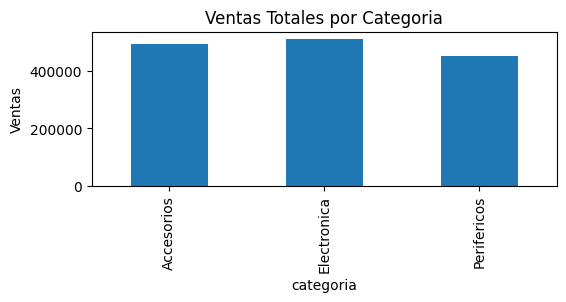

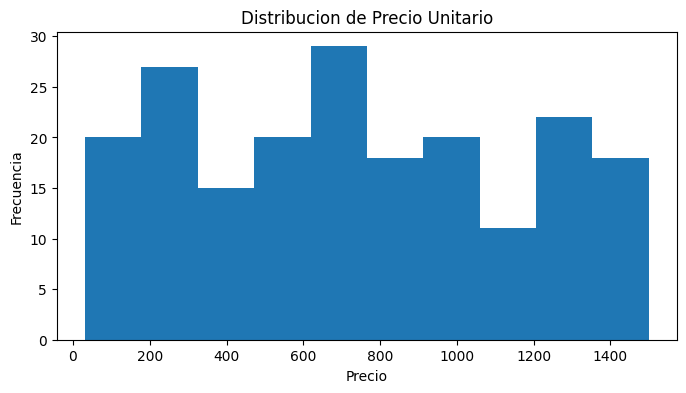

[INFO] DataAnalyst: Analisis y visualizaciones completados


In [ ]:
# Prueba DataAnalyst
analyst = DataAnalyst(df_clean)
analyst.execute()


---
## Paso 6: El "main" del Notebook — orquestando el pipeline

Ahora que todas las piezas estan listas, las conectamos. Esta celda es el **punto de entrada** del sistema: instancia los objetos en orden y pasa los datos de uno al siguiente.

Observa como el codigo principal no sabe nada de los detalles internos de cada clase. Solo sabe que todos tienen `.execute()`. Eso es abstraccion.


Iniciando pipeline de datos
[INFO] DataLoader: Archivo cargado correctamente (200 filas, 6 columnas)
[INFO] DataCleaner: Nulos antes: 106 | Nulos despues: 0

Ventas por categoria:
categoria
Accesorios     492683.070
Electronica    511708.365
Perifericos    453263.345
Name: ventas_totales, dtype: float64

Producto mas vendido: Monitor
Region con mas ventas: Sur


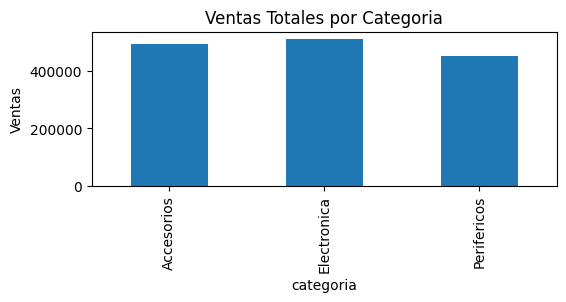

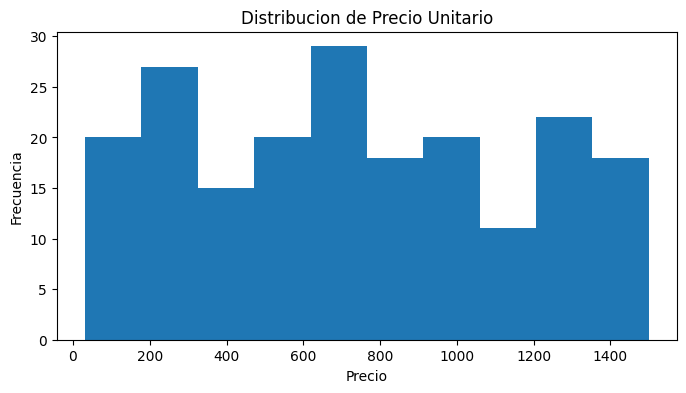

[INFO] DataAnalyst: Analisis y visualizaciones completados
Pipeline finalizado.


In [ ]:
# Paso 6: Pipeline completo
# ---------------------------------------------------------------------------
# Instancia los tres objetos y ejecuta el flujo completo.
# El output de cada paso es el input del siguiente.

print("=" * 50)
print("Iniciando pipeline de datos")
print("=" * 50)

# --- Ingesta ---
loader  = DataLoader("ventas.csv")
df_raw  = loader.execute()

# --- Transformacion ---
cleaner  = DataCleaner(df_raw)
df_clean = cleaner.execute()

# --- Analisis ---
analyst = DataAnalyst(df_clean)
analyst.execute()

print("=" * 50)
print("Pipeline finalizado.")
print("=" * 50)


---
# Ejercicio final (trabajo individual)

Felicitaciones — acabas de construir un pipeline de datos con POO desde cero.

Ahora es tu turno de aplicar lo aprendido en un escenario diferente.

---

## Contexto

Tienes acceso a un dataset de **empleados** de una empresa. El archivo se crea en la celda siguiente. Tu tarea es construir tu propio mini-pipeline siguiendo la misma arquitectura que aprendiste, pero adaptandola a este nuevo dominio.

---

## Dataset


In [ ]:
# Dataset de empleados — ejecuta esta celda para crear el archivo
np.random.seed(7)
n = 150

empleados = {
    "id_empleado": range(1, n + 1),
    "nombre": [f"Empleado_{i}" for i in range(1, n + 1)],
    "departamento": np.random.choice(["Ventas", "IT", "RRHH", "Finanzas", None], n),
    "salario": np.round(np.random.uniform(800, 5000, n), 2),
    "anos_experiencia": np.random.randint(0, 20, n).astype(float),
    "evaluacion": np.random.choice([1, 2, 3, 4, 5, None], n),
    "fecha_ingreso": pd.date_range("2015-01-01", periods=n, freq="15D").astype(str),
}

df_emp = pd.DataFrame(empleados)
# Introducimos nulos
df_emp.loc[np.random.choice(df_emp.index, 12, replace=False), "salario"] = np.nan
df_emp.loc[np.random.choice(df_emp.index, 8, replace=False), "anos_experiencia"] = np.nan

df_emp.to_csv("empleados.csv", index=False)
print(f"Archivo 'empleados.csv' creado con {len(df_emp)} filas.")
df_emp.head()


Archivo 'empleados.csv' creado con 150 filas.


,id_empleado,nombre,departamento,salario,anos_experiencia,evaluacion,fecha_ingreso
0,1,Empleado_1,None,4085.37,NaN,None,2015-01-01
1,2,Empleado_2,IT,4399.30,14.0,1,2015-01-16
2,3,Empleado_3,Finanzas,941.43,14.0,5,2015-01-31
3,4,Empleado_4,Finanzas,3037.11,4.0,3,2015-02-15
4,5,Empleado_5,None,4147.20,19.0,1,2015-03-02


## Instrucciones

Construye un pipeline para este dataset. Puedes reutilizar los Mixins y la clase abstracta que ya escribiste — no los reescribas, solo importalos o asegurate de que esten en el mismo notebook.

**Lo que debes implementar:**

### 1. `EmployeeLoader`
- Hereda de `DataComponent`, `ValidatorMixin` y `LoggerMixin`.
- Carga el archivo `empleados.csv`.
- **Diferencia respecto al taller:** valida ademas que el DataFrame tenga las columnas `["id_empleado", "salario", "departamento"]` antes de retornarlo. Usa `validate_columns()` del Mixin.

### 2. `EmployeeCleaner`
- Hereda de `DataComponent` y `LoggerMixin`.
- Imputa nulos (misma logica: mediana para numericos, "Desconocido" para texto).
- **Diferencia respecto al taller:** agrega una columna calculada `salario_anual = salario * 12` durante la limpieza.
- Implementa un `@property` llamado `stats` que retorne el salario promedio y mediano por departamento.

### 3. `EmployeeAnalyst`
- Hereda de `DataComponent` y `LoggerMixin`.
- `report_console()`: muestra el salario promedio por departamento y el top 5 de empleados mejor pagados.
- `report_visual()`: genera **al menos un grafico diferente** a los del taller (por ejemplo: boxplot de salario por departamento, o scatter de anos_experiencia vs salario).

### 4. Pipeline final
- Conecta los tres objetos en secuencia en una sola celda.

---

**Pista:** si algo no funciona, revisa que `execute()` este retornando el DataFrame — es el error mas comun al encadenar el pipeline.


In [ ]:
# Tu implementacion: EmployeeLoader
# ---------------------------------------------------------------------------

class EmployeeLoader(DataComponent, ValidatorMixin, LoggerMixin):
    pass


In [ ]:
# Tu implementacion: EmployeeCleaner
# ---------------------------------------------------------------------------

class EmployeeCleaner(DataComponent, LoggerMixin):
    pass


In [ ]:
# Tu implementacion: EmployeeAnalyst
# ---------------------------------------------------------------------------

class EmployeeAnalyst(DataComponent, LoggerMixin):
    pass


In [ ]:
# Pipeline final del ejercicio
# ---------------------------------------------------------------------------

print("=" * 50)
print("Pipeline de empleados")
print("=" * 50)

# Escribe aqui el flujo completo


Pipeline de empleados


---
## Cierre del taller

Hoy aplicaste los cuatro pilares de la POO en un contexto real de ciencia de datos:

| Concepto | Donde lo usaste |
|---|---|
| **Abstraccion** | `DataComponent` con `@abstractmethod` |
| **Herencia** | Todas las clases heredan de `DataComponent` y los Mixins |
| **Encapsulamiento** | Atributos privados (`__file_path`, `__df`) y `@property` |
| **Polimorfismo** | `report_console()` y `report_visual()` como formas distintas de "analizar" |

La arquitectura que construiste hoy — una clase abstracta + Mixins + clases concretas + un pipeline orquestador — es el patron que encontraras en librerias reales como `scikit-learn` (donde todos los modelos tienen `.fit()` y `.predict()`).

**Recursos para profundizar:**
- [The Python Tutorial: Classes](https://docs.python.org/3/tutorial/classes.html)
- [Real Python: Inheritance and Composition](https://realpython.com/inheritance-composition-python/)
- [Real Python: Python's property()](https://realpython.com/python-property/)


## Corrección del ejercicio

In [ ]:
# Tu implementacion: EmployeeLoader
# ---------------------------------------------------------------------------

class EmployeeLoader(DataComponent, ValidatorMixin, LoggerMixin):  # Carga y valida datos de empleados

    def __init__(self, file_path):  # Recibe la ruta del archivo
        self.__file_path = file_path  # Guarda la ruta como atributo privado

    def execute(self):  # Ejecuta la carga de datos

        self.validate_file(self.__file_path)  # Verifica que el archivo exista

        df = pd.read_csv(self.__file_path)  # Lee el archivo CSV

        self.validate_columns(
            df,
            ["id_empleado", "salario", "departamento"]
        )  # Verifica columnas obligatorias

        self.log(
            f"Archivo cargado correctamente ({df.shape[0]} filas, {df.shape[1]} columnas)"
        )  # Registra informacion de la carga

        return df  # Devuelve el DataFrame

In [ ]:
# Tu implementacion: EmployeeCleaner
# ---------------------------------------------------------------------------

class EmployeeCleaner(DataComponent, LoggerMixin):  # Limpia y transforma datos de empleados

    def __init__(self, df):  # Recibe el DataFrame
        self.__df = df  # Guarda el DataFrame como atributo privado

    def execute(self):  # Ejecuta la limpieza

        nulls_before = self.__df.isna().sum().sum()  # Cuenta nulos antes

        # Columnas numericas
        numeric_cols = self.__df.select_dtypes(include="number").columns

        # Imputa nulos numericos con la mediana
        for col in numeric_cols:
            self.__df[col] = self.__df[col].fillna(self.__df[col].median())

        # Columnas de texto
        text_cols = self.__df.select_dtypes(include="object").columns

        # Imputa nulos de texto con "Desconocido"
        for col in text_cols:
            self.__df[col] = self.__df[col].fillna("Desconocido")

        # Nueva columna calculada
        self.__df["salario_anual"] = self.__df["salario"] * 12

        nulls_after = self.__df.isna().sum().sum()  # Cuenta nulos despues

        self.log(
            f"Nulos antes: {nulls_before} | Nulos despues: {nulls_after}"
        )  # Registra el resultado

        return self.__df  # Devuelve el DataFrame limpio

    @property
    def stats(self):  # Estadisticas por departamento
        return self.__df.groupby("departamento")["salario"].agg(
            promedio="mean",
            mediana="median"
        ).to_dict()

In [ ]:
# Tu implementacion: EmployeeAnalyst
# ---------------------------------------------------------------------------

class EmployeeAnalyst(DataComponent, LoggerMixin):  # Analiza datos de empleados

    def __init__(self, df):  # Recibe el DataFrame limpio
        self.__df = df  # Guarda el DataFrame como atributo privado

    def execute(self):  # Ejecuta el analisis completo
        self.report_console()  # Reporte en consola
        self.report_visual()  # Reporte grafico

    def report_console(self):  # Muestra estadisticas en consola

        salario_promedio = self.__df.groupby("departamento")[
            "salario"
        ].mean()  # Salario promedio por departamento

        top_5 = self.__df.nlargest(
            5, "salario"
        )  # Top 5 empleados mejor pagados

        print("\nSalario promedio por departamento:")
        print(salario_promedio)

        print("\nTop 5 empleados mejor pagados:")
        print(top_5)

    def report_visual(self):  # Genera visualizaciones

        # Boxplot de salario por departamento
        plt.figure(figsize=(8, 4))

        self.__df.boxplot(
            column="salario",
            by="departamento"
        )

        plt.title("Salario por Departamento")
        plt.suptitle("")  # Oculta titulo automatico de pandas
        plt.ylabel("Salario")

        plt.show()

        self.log("Analisis completado")

Pipeline de empleados
[INFO] EmployeeLoader: Archivo cargado correctamente (150 filas, 7 columnas)
[INFO] EmployeeCleaner: Nulos antes: 85 | Nulos despues: 0

Estadisticas por departamento:
{'promedio': {'Desconocido': 2967.871756756757, 'Finanzas': 2700.546891891892, 'IT': 3348.9762068965515, 'RRHH': 3071.78825, 'Ventas': 2614.701666666667}, 'mediana': {'Desconocido': 3012.6850000000004, 'Finanzas': 3012.6850000000004, 'IT': 3441.18, 'RRHH': 2877.1225000000004, 'Ventas': 2318.15}}

Salario promedio por departamento:
departamento
Desconocido    2967.871757
Finanzas       2700.546892
IT             3348.976207
RRHH           3071.788250
Ventas         2614.701667
Name: salario, dtype: float64

Top 5 empleados mejor pagados:
     id_empleado        nombre departamento  salario  anos_experiencia  \
92            93   Empleado_93  Desconocido  4952.26               9.0   
137          138  Empleado_138           IT  4937.92               4.0   
5              6    Empleado_6           IT  

<Figure size 800x400 with 0 Axes>

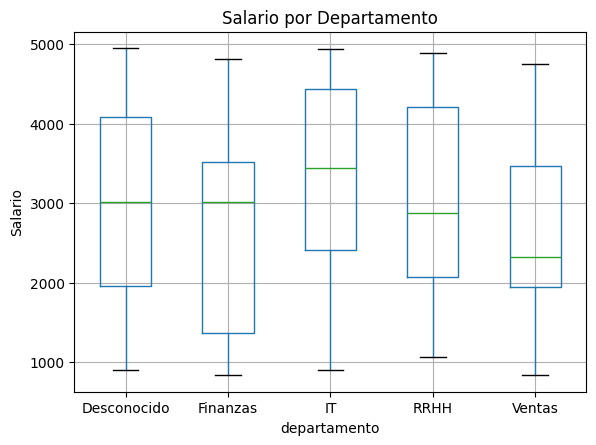

[INFO] EmployeeAnalyst: Analisis completado


In [ ]:
# Pipeline final del ejercicio
# ---------------------------------------------------------------------------

print("=" * 50)
print("Pipeline de empleados")
print("=" * 50)

# Carga de datos
loader = EmployeeLoader("empleados.csv")
df = loader.execute()

# Limpieza de datos
cleaner = EmployeeCleaner(df)
df_clean = cleaner.execute()

# Estadisticas del DataFrame limpio
print("\nEstadisticas por departamento:")
print(cleaner.stats)

# Analisis de datos
analyst = EmployeeAnalyst(df_clean)
analyst.execute()